# 03 — XGBoost Baseline

Notebook ini melatih **baseline traditional machine learning** untuk deteksi AI-generated code.

Model:
- **XGBoost Classifier**

Input model:
- `code` saja sebagai sumber utama fitur
- Tidak memakai metadata seperti `dataset_origin`, `LLM`, `status_in_folder`, `problem_id`, `group_id`, atau `leakage_group`

Fitur:
1. **TF-IDF character n-gram** dari source code
2. **Fitur statistik kode** yang dihitung langsung dari isi kode

Output:
- Model XGBoost tersimpan
- Vectorizer dan scaler tersimpan
- Prediksi validation dan test tersimpan
- Metrics validation dan test tersimpan
- Confusion matrix tersimpan

Notebook ini membuat model baseline dengan XGBoost.

## Preprocessing pada model ini

Preprocessing yang dilakukan di notebook ini:
- mengubah source code menjadi fitur teks memakai TF-IDF character n-gram
- membuat fitur statistik kode, seperti jumlah baris, panjang kode, jumlah `if`, `for`, `return`, dan simbol
- menormalkan fitur statistik dengan scaler
- menggabungkan fitur TF-IDF dan fitur statistik menjadi input XGBoost

## Penjelasan model

XGBoost bukan neural network, jadi tidak punya layer seperti BiLSTM atau CodeBERT.
Model ini bekerja dengan banyak decision tree yang digabungkan secara bertahap.
Tidak ada top layer tambahan. Yang ditambahkan adalah fitur input berupa TF-IDF dan statistik kode.

In [1]:
!pip -q install xgboost scikit-learn joblib

## 1. Import library dan load path project

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import json
import time
import joblib
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_DIR = "/content/drive/MyDrive/FP AI"
SRC_DIR = os.path.join(PROJECT_DIR, "src")
sys.path.append(SRC_DIR)

try:
    from config import *
    print("config.py loaded.")
except Exception:
    print("config.py not found. Using fallback paths.")
    RAW_DIR = os.path.join(PROJECT_DIR, "data", "raw")
    PROCESSED_DIR = os.path.join(PROJECT_DIR, "data", "processed")
    SPLIT_DIR = os.path.join(PROJECT_DIR, "data", "splits")
    EDA_DIR = os.path.join(PROJECT_DIR, "outputs", "eda")
    MODEL_DIR = os.path.join(PROJECT_DIR, "outputs", "models")
    PREDICTION_DIR = os.path.join(PROJECT_DIR, "outputs", "predictions")
    METRIC_DIR = os.path.join(PROJECT_DIR, "outputs", "metrics")
    FIGURE_DIR = os.path.join(PROJECT_DIR, "outputs", "figures")
    RANDOM_STATE = 42

for folder in [MODEL_DIR, PREDICTION_DIR, METRIC_DIR, FIGURE_DIR]:
    os.makedirs(folder, exist_ok=True)

XGB_MODEL_DIR = os.path.join(MODEL_DIR, "xgboost")
XGB_FIGURE_DIR = os.path.join(FIGURE_DIR, "xgboost")
os.makedirs(XGB_MODEL_DIR, exist_ok=True)
os.makedirs(XGB_FIGURE_DIR, exist_ok=True)

RANDOM_STATE = 42

print("PROJECT_DIR:", PROJECT_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("XGB_MODEL_DIR:", XGB_MODEL_DIR)

Mounted at /content/drive
config.py loaded.
PROJECT_DIR: /content/drive/MyDrive/FP AI
SPLIT_DIR: /content/drive/MyDrive/FP AI/data/splits
XGB_MODEL_DIR: /content/drive/MyDrive/FP AI/outputs/models/xgboost


## 2. Load train, validation, dan test split

In [3]:
train_path = os.path.join(SPLIT_DIR, "train.csv")
valid_path = os.path.join(SPLIT_DIR, "valid.csv")
test_path = os.path.join(SPLIT_DIR, "test.csv")

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (744, 11)
Valid shape: (164, 11)
Test shape: (172, 11)


,problem_id,group_id,leakage_group,code_hash,code,label,dataset_origin,source_type,status_in_folder,LLM,hf_split
0,p02954,open_p02954,lg_00002,8e5962d3a5bad724b2ce411df1df0b85,s = input()\nn = len(s)\ncounts = [0] * n\nfor i in range(n):\n if s[i] == 'R':\n counts[(i + 1) % n] += 1...,1,open,ai,Generate,GEMINI,test
1,p02640,open_p02640,lg_00003,ddc7e61578e1d8cb72612564cad62a4f,"def solve(X, Y):\n if X == Y:\n return ""Yes""\n elif X < Y:\n return ""No""\n else:\n ret...",1,open,ai,Generate,LLAMA,train
2,p03643,open_p03643,lg_00004,26cf1b3f9816aecfdc848762c0d935ca,"print(f""ABC{int(input())}"")",1,open,ai,Generate,CODESTRAL,train
3,p02769,open_p02769,lg_00005,5bfbfaa6bfdd59987faa29095f73be93,import sys\nread = sys.stdin.read\nreadline = sys.stdin.readline\nreadlines = sys.stdin.readlines\n\nMOD = 10**9+7\n...,0,open,human,Accepted,Human,train
4,p02685,open_p02685,lg_00007,df6147be35a53f74db70decb96459dd2,"#factorial\nMOD = 998244353\nN = 1000000\nmodinv_t = [0, 1]\nmodfact_t = [1, 1]\nmodfactinv_t = [1, 1]\nfor i in ran...",0,open,human,Accepted,Human,train


## 3. Audit singkat split

In [4]:
def show_basic_split_info(name, df):
    print(f"\n===== {name} =====")
    print("Rows:", len(df))
    print("Label distribution:")
    print(df["label"].value_counts().sort_index())
    print("Origin distribution:")
    print(df["dataset_origin"].value_counts())

show_basic_split_info("TRAIN", train_df)
show_basic_split_info("VALID", valid_df)
show_basic_split_info("TEST", test_df)

# Pastikan hanya memakai kolom code sebagai input utama model
required_cols = ["code", "label"]
for df_name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in {df_name}: {missing_cols}")

# Cek leakage group kalau kolomnya tersedia
for col in ["leakage_group", "group_id", "code_hash"]:
    if col in train_df.columns:
        train_set = set(train_df[col])
        valid_set = set(valid_df[col])
        test_set = set(test_df[col])
        print(f"\nOverlap check for {col}:")
        print("Train-valid:", len(train_set & valid_set))
        print("Train-test:", len(train_set & test_set))
        print("Valid-test:", len(valid_set & test_set))


===== TRAIN =====
Rows: 744
Label distribution:
label
0    369
1    375
Name: count, dtype: int64
Origin distribution:
dataset_origin
open    512
self    232
Name: count, dtype: int64

===== VALID =====
Rows: 164
Label distribution:
label
0    84
1    80
Name: count, dtype: int64
Origin distribution:
dataset_origin
open    128
self     36
Name: count, dtype: int64

===== TEST =====
Rows: 172
Label distribution:
label
0    87
1    85
Name: count, dtype: int64
Origin distribution:
dataset_origin
open    116
self     56
Name: count, dtype: int64

Overlap check for leakage_group:
Train-valid: 0
Train-test: 0
Valid-test: 0

Overlap check for group_id:
Train-valid: 0
Train-test: 0
Valid-test: 0

Overlap check for code_hash:
Train-valid: 0
Train-test: 0
Valid-test: 0


## 4. Preprocessing — fitur statistik kode

In [5]:
def extract_code_features(code):
    code = str(code)
    lines = code.split("\n")
    stripped_lines = [line.strip() for line in lines]
    non_empty_lines = [line for line in stripped_lines if line != ""]
    comment_lines = [line for line in stripped_lines if line.startswith("#")]

    char_count = len(code)
    line_count = len(lines)
    non_empty_line_count = len(non_empty_lines)
    blank_line_count = line_count - non_empty_line_count

    avg_line_length = char_count / max(line_count, 1)
    max_line_length = max([len(line) for line in lines]) if lines else 0

    indentation_spaces = sum(len(line) - len(line.lstrip(" ")) for line in lines)
    tab_count = code.count("\t")

    # token-ish counts
    def_count = len(re.findall(r"\bdef\b", code))
    class_count = len(re.findall(r"\bclass\b", code))
    return_count = len(re.findall(r"\breturn\b", code))
    if_count = len(re.findall(r"\bif\b", code))
    elif_count = len(re.findall(r"\belif\b", code))
    else_count = len(re.findall(r"\belse\b", code))
    for_count = len(re.findall(r"\bfor\b", code))
    while_count = len(re.findall(r"\bwhile\b", code))
    import_count = len(re.findall(r"\bimport\b", code))
    try_count = len(re.findall(r"\btry\b", code))
    except_count = len(re.findall(r"\bexcept\b", code))

    operator_count = sum(code.count(op) for op in ["+", "-", "*", "/", "%", "==", "!=", "<=", ">=", "<", ">", "="])
    bracket_count = sum(code.count(ch) for ch in ["(", ")", "[", "]", "{", "}"])
    comma_count = code.count(",")
    colon_count = code.count(":")
    dot_count = code.count(".")

    unique_chars = len(set(code))
    digit_count = sum(ch.isdigit() for ch in code)
    alpha_count = sum(ch.isalpha() for ch in code)
    whitespace_count = sum(ch.isspace() for ch in code)

    comment_count = len(comment_lines)
    comment_ratio = comment_count / max(line_count, 1)
    blank_line_ratio = blank_line_count / max(line_count, 1)

    return {
        "char_count": char_count,
        "line_count": line_count,
        "non_empty_line_count": non_empty_line_count,
        "blank_line_count": blank_line_count,
        "avg_line_length": avg_line_length,
        "max_line_length": max_line_length,
        "indentation_spaces": indentation_spaces,
        "tab_count": tab_count,
        "def_count": def_count,
        "class_count": class_count,
        "return_count": return_count,
        "if_count": if_count,
        "elif_count": elif_count,
        "else_count": else_count,
        "for_count": for_count,
        "while_count": while_count,
        "import_count": import_count,
        "try_count": try_count,
        "except_count": except_count,
        "operator_count": operator_count,
        "bracket_count": bracket_count,
        "comma_count": comma_count,
        "colon_count": colon_count,
        "dot_count": dot_count,
        "unique_chars": unique_chars,
        "digit_count": digit_count,
        "alpha_count": alpha_count,
        "whitespace_count": whitespace_count,
        "comment_count": comment_count,
        "comment_ratio": comment_ratio,
        "blank_line_ratio": blank_line_ratio,
    }


def build_stat_feature_df(codes):
    features = [extract_code_features(code) for code in codes]
    return pd.DataFrame(features)


train_stat_df = build_stat_feature_df(train_df["code"])
valid_stat_df = build_stat_feature_df(valid_df["code"])
test_stat_df = build_stat_feature_df(test_df["code"])

print("Stat feature shape train:", train_stat_df.shape)
display(train_stat_df.head())

Stat feature shape train: (744, 31)


,char_count,line_count,non_empty_line_count,blank_line_count,avg_line_length,max_line_length,indentation_spaces,tab_count,def_count,class_count,return_count,if_count,elif_count,else_count,for_count,while_count,import_count,try_count,except_count,operator_count,bracket_count,comma_count,colon_count,dot_count,unique_chars,digit_count,alpha_count,whitespace_count,comment_count,comment_ratio,blank_line_ratio
0,169,9,9,0,18.777778,32,24,0,0,0,0,1,0,1,1,0,0,0,0,16,20,0,3,0,30,5,66,58,0,0.000000,0.000000
1,163,7,7,0,23.285714,64,36,0,1,0,3,2,1,2,0,0,0,0,0,14,2,1,4,0,31,4,64,69,0,0.000000,0.000000
2,27,1,1,0,27.000000,27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,15,0,17,0,0,0.000000,0.000000
3,719,40,27,13,17.975000,54,84,0,3,0,2,2,0,0,2,0,1,0,0,44,62,15,7,10,48,22,338,207,0,0.000000,0.325000
4,652,29,27,2,22.482759,66,16,0,3,0,3,0,0,0,2,0,0,0,0,45,62,17,5,4,52,35,351,112,6,0.206897,0.068966


## 5. Preprocessing — TF-IDF character n-gram

In [6]:
tfidf_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=5000,
    min_df=2,
    lowercase=False
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["code"].astype(str))
X_valid_tfidf = tfidf_vectorizer.transform(valid_df["code"].astype(str))
X_test_tfidf = tfidf_vectorizer.transform(test_df["code"].astype(str))

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF valid shape:", X_valid_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (744, 5000)
TF-IDF valid shape: (164, 5000)
TF-IDF test shape: (172, 5000)


## 6. Preprocessing — gabungkan TF-IDF dan fitur statistik

In [7]:
scaler = StandardScaler()

X_train_stat = scaler.fit_transform(train_stat_df)
X_valid_stat = scaler.transform(valid_stat_df)
X_test_stat = scaler.transform(test_stat_df)

X_train = hstack([X_train_tfidf, csr_matrix(X_train_stat)])
X_valid = hstack([X_valid_tfidf, csr_matrix(X_valid_stat)])
X_test = hstack([X_test_tfidf, csr_matrix(X_test_stat)])

y_train = train_df["label"].astype(int).values
y_valid = valid_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

print("Combined train shape:", X_train.shape)
print("Combined valid shape:", X_valid.shape)
print("Combined test shape:", X_test.shape)

Combined train shape: (744, 5031)
Combined valid shape: (164, 5031)
Combined test shape: (172, 5031)


## 7. Train XGBoost baseline

In [8]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

train_start = time.time()

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

train_end = time.time()
training_time_seconds = train_end - train_start

print(f"Training time: {training_time_seconds:.4f} seconds")

Training time: 49.3936 seconds


## 8. Threshold tuning berdasarkan validation F1

In [9]:
valid_proba = xgb_model.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    preds = (valid_proba >= threshold).astype(int)
    threshold_results.append({
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_valid, preds),
        "precision": precision_score(y_valid, preds, zero_division=0),
        "recall": recall_score(y_valid, preds, zero_division=0),
        "f1": f1_score(y_valid, preds, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_row = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
best_threshold = float(best_row["threshold"])

print("Best threshold based on validation F1:", best_threshold)
display(best_row.to_frame().T)

threshold_path = os.path.join(METRIC_DIR, "xgboost_threshold_search.csv")
threshold_df.to_csv(threshold_path, index=False)
print("Saved threshold search:", threshold_path)

Best threshold based on validation F1: 0.6299999999999997


,threshold,accuracy,precision,recall,f1
53,0.63,0.945122,0.949367,0.9375,0.943396


Saved threshold search: /content/drive/MyDrive/FP AI/outputs/metrics/xgboost_threshold_search.csv


## 9. Evaluation helper

In [10]:
def evaluate_binary_classifier(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
    except Exception:
        metrics["roc_auc"] = None

    cm = confusion_matrix(y_true, y_pred)

    return metrics, y_pred, cm


def plot_confusion_matrix(cm, title, save_path):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Human (0)", "AI (1)"])
    plt.yticks([0, 1], ["Human (0)", "AI (1)"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

## 10. Evaluate validation dan test set

In [11]:
# Validation inference time
valid_start = time.time()
valid_proba = xgb_model.predict_proba(X_valid)[:, 1]
valid_end = time.time()
valid_inference_time_seconds = valid_end - valid_start

valid_metrics, valid_pred, valid_cm = evaluate_binary_classifier(
    y_valid,
    valid_proba,
    threshold=best_threshold
)

# Test inference time
test_start = time.time()
test_proba = xgb_model.predict_proba(X_test)[:, 1]
test_end = time.time()
test_inference_time_seconds = test_end - test_start

test_metrics, test_pred, test_cm = evaluate_binary_classifier(
    y_test,
    test_proba,
    threshold=best_threshold
)

print("Validation metrics:")
print(json.dumps(valid_metrics, indent=4))

print("\nTest metrics:")
print(json.dumps(test_metrics, indent=4))

print("\nValidation classification report:")
print(classification_report(y_valid, valid_pred, target_names=["Human", "AI"], zero_division=0))

print("\nTest classification report:")
print(classification_report(y_test, test_pred, target_names=["Human", "AI"], zero_division=0))

print(f"Validation inference time: {valid_inference_time_seconds:.6f} seconds")
print(f"Test inference time: {test_inference_time_seconds:.6f} seconds")
print(f"Test inference time per sample: {test_inference_time_seconds / len(test_df):.8f} seconds")

Validation metrics:
{
    "accuracy": 0.9451219512195121,
    "precision": 0.9493670886075949,
    "recall": 0.9375,
    "f1": 0.9433962264150944,
    "roc_auc": 0.984672619047619
}

Test metrics:
{
    "accuracy": 0.8604651162790697,
    "precision": 0.8860759493670886,
    "recall": 0.8235294117647058,
    "f1": 0.8536585365853658,
    "roc_auc": 0.9529411764705883
}

Validation classification report:
              precision    recall  f1-score   support

       Human       0.94      0.95      0.95        84
          AI       0.95      0.94      0.94        80

    accuracy                           0.95       164
   macro avg       0.95      0.94      0.95       164
weighted avg       0.95      0.95      0.95       164


Test classification report:
              precision    recall  f1-score   support

       Human       0.84      0.90      0.87        87
          AI       0.89      0.82      0.85        85

    accuracy                           0.86       172
   macro avg       

## 11. Plot confusion matrix

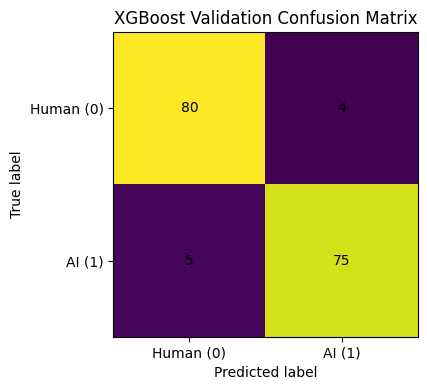

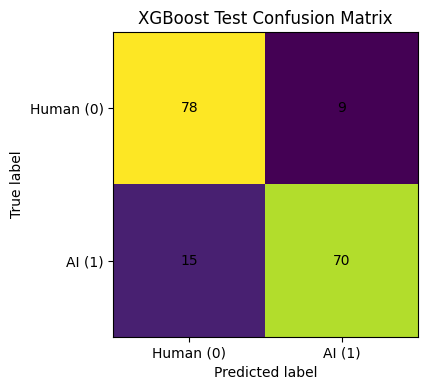

Saved validation confusion matrix: /content/drive/MyDrive/FP AI/outputs/figures/xgboost/xgboost_valid_confusion_matrix.png
Saved test confusion matrix: /content/drive/MyDrive/FP AI/outputs/figures/xgboost/xgboost_test_confusion_matrix.png


In [12]:
valid_cm_path = os.path.join(XGB_FIGURE_DIR, "xgboost_valid_confusion_matrix.png")
test_cm_path = os.path.join(XGB_FIGURE_DIR, "xgboost_test_confusion_matrix.png")

plot_confusion_matrix(
    valid_cm,
    "XGBoost Validation Confusion Matrix",
    valid_cm_path
)

plot_confusion_matrix(
    test_cm,
    "XGBoost Test Confusion Matrix",
    test_cm_path
)

print("Saved validation confusion matrix:", valid_cm_path)
print("Saved test confusion matrix:", test_cm_path)

## 12. Simpan prediction file

In [13]:
valid_pred_df = valid_df.copy()
valid_pred_df["y_true"] = y_valid
valid_pred_df["y_proba_ai"] = valid_proba
valid_pred_df["y_pred"] = valid_pred
valid_pred_df["model"] = "xgboost"

test_pred_df = test_df.copy()
test_pred_df["y_true"] = y_test
test_pred_df["y_proba_ai"] = test_proba
test_pred_df["y_pred"] = test_pred
test_pred_df["model"] = "xgboost"

valid_pred_path = os.path.join(PREDICTION_DIR, "xgboost_valid_predictions.csv")
test_pred_path = os.path.join(PREDICTION_DIR, "xgboost_test_predictions.csv")

valid_pred_df.to_csv(valid_pred_path, index=False)
test_pred_df.to_csv(test_pred_path, index=False)

print("Saved validation predictions:", valid_pred_path)
print("Saved test predictions:", test_pred_path)

display(test_pred_df[["problem_id", "label", "y_true", "y_pred", "y_proba_ai", "dataset_origin", "status_in_folder"]].head())

Saved validation predictions: /content/drive/MyDrive/FP AI/outputs/predictions/xgboost_valid_predictions.csv
Saved test predictions: /content/drive/MyDrive/FP AI/outputs/predictions/xgboost_test_predictions.csv


,problem_id,label,y_true,y_pred,y_proba_ai,dataset_origin,status_in_folder
0,p02777,1,1,1,0.942845,open,Generate
1,p03760,1,1,1,0.925913,open,Generate
2,p02662,0,0,0,0.001176,open,Accepted
3,p02574,0,0,0,0.013782,open,Accepted
4,p03606,1,1,1,0.994679,open,Generate


## 13. Simpan metrics

In [14]:
xgboost_summary = {
    "model": "XGBoost",
    "feature_type": "TF-IDF char ngram 3-5 + statistical code features",
    "input_used": "code only",
    "metadata_excluded": [
        "problem_id",
        "group_id",
        "leakage_group",
        "code_hash",
        "dataset_origin",
        "source_type",
        "status_in_folder",
        "LLM",
        "hf_split"
    ],
    "best_threshold_from_validation": best_threshold,
    "training_time_seconds": float(training_time_seconds),
    "validation_inference_time_seconds": float(valid_inference_time_seconds),
    "test_inference_time_seconds": float(test_inference_time_seconds),
    "test_inference_time_per_sample_seconds": float(test_inference_time_seconds / len(test_df)),
    "n_train": int(len(train_df)),
    "n_valid": int(len(valid_df)),
    "n_test": int(len(test_df)),
    "n_features": int(X_train.shape[1]),
    "tfidf_features": int(X_train_tfidf.shape[1]),
    "statistical_features": int(train_stat_df.shape[1]),
    "model_params": xgb_model.get_params(),
    "validation_metrics": valid_metrics,
    "test_metrics": test_metrics,
    "validation_confusion_matrix": valid_cm.tolist(),
    "test_confusion_matrix": test_cm.tolist(),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

summary_json_path = os.path.join(METRIC_DIR, "xgboost_metrics.json")
summary_csv_path = os.path.join(METRIC_DIR, "xgboost_metrics.csv")

with open(summary_json_path, "w") as f:
    json.dump(xgboost_summary, f, indent=4)

metrics_rows = [
    {
        "model": "XGBoost",
        "split": "validation",
        **valid_metrics,
        "training_time_seconds": training_time_seconds,
        "inference_time_seconds": valid_inference_time_seconds,
        "inference_time_per_sample_seconds": valid_inference_time_seconds / len(valid_df),
        "threshold": best_threshold,
        "n_features": X_train.shape[1],
    },
    {
        "model": "XGBoost",
        "split": "test",
        **test_metrics,
        "training_time_seconds": training_time_seconds,
        "inference_time_seconds": test_inference_time_seconds,
        "inference_time_per_sample_seconds": test_inference_time_seconds / len(test_df),
        "threshold": best_threshold,
        "n_features": X_train.shape[1],
    }
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(summary_csv_path, index=False)

print("Saved metrics JSON:", summary_json_path)
print("Saved metrics CSV:", summary_csv_path)
display(metrics_df)

Saved metrics JSON: /content/drive/MyDrive/FP AI/outputs/metrics/xgboost_metrics.json
Saved metrics CSV: /content/drive/MyDrive/FP AI/outputs/metrics/xgboost_metrics.csv


,model,split,accuracy,precision,recall,f1,roc_auc,training_time_seconds,inference_time_seconds,inference_time_per_sample_seconds,threshold,n_features
0,XGBoost,validation,0.945122,0.949367,0.937500,0.943396,0.984673,49.393586,0.005497,0.000034,0.63,5031
1,XGBoost,test,0.860465,0.886076,0.823529,0.853659,0.952941,49.393586,0.003624,0.000021,0.63,5031


## 14. Simpan model, vectorizer, scaler, dan feature columns

In [15]:
model_path = os.path.join(XGB_MODEL_DIR, "xgboost_model.pkl")
vectorizer_path = os.path.join(XGB_MODEL_DIR, "tfidf_vectorizer.pkl")
scaler_path = os.path.join(XGB_MODEL_DIR, "stat_scaler.pkl")
stat_columns_path = os.path.join(XGB_MODEL_DIR, "stat_feature_columns.json")
threshold_save_path = os.path.join(XGB_MODEL_DIR, "best_threshold.json")

joblib.dump(xgb_model, model_path)
joblib.dump(tfidf_vectorizer, vectorizer_path)
joblib.dump(scaler, scaler_path)

with open(stat_columns_path, "w") as f:
    json.dump(train_stat_df.columns.tolist(), f, indent=4)

with open(threshold_save_path, "w") as f:
    json.dump({"best_threshold": best_threshold}, f, indent=4)

print("Saved model:", model_path)
print("Saved vectorizer:", vectorizer_path)
print("Saved scaler:", scaler_path)
print("Saved stat feature columns:", stat_columns_path)
print("Saved best threshold:", threshold_save_path)

Saved model: /content/drive/MyDrive/FP AI/outputs/models/xgboost/xgboost_model.pkl
Saved vectorizer: /content/drive/MyDrive/FP AI/outputs/models/xgboost/tfidf_vectorizer.pkl
Saved scaler: /content/drive/MyDrive/FP AI/outputs/models/xgboost/stat_scaler.pkl
Saved stat feature columns: /content/drive/MyDrive/FP AI/outputs/models/xgboost/stat_feature_columns.json
Saved best threshold: /content/drive/MyDrive/FP AI/outputs/models/xgboost/best_threshold.json


## 15. Feature importance sederhana

In [16]:
# Feature importance dari XGBoost.
# Catatan: karena fitur TF-IDF sangat banyak, interpretasi feature importance hanya sebagai indikasi awal.

booster = xgb_model.get_booster()
importance_dict = booster.get_score(importance_type="gain")

importance_df = pd.DataFrame(
    [{"feature": k, "gain": v} for k, v in importance_dict.items()]
).sort_values("gain", ascending=False)

importance_path = os.path.join(METRIC_DIR, "xgboost_feature_importance_gain.csv")
importance_df.to_csv(importance_path, index=False)

print("Saved feature importance:", importance_path)
display(importance_df.head(20))

Saved feature importance: /content/drive/MyDrive/FP AI/outputs/metrics/xgboost_feature_importance_gain.csv


,feature,gain
426,f4663,52.092194
383,f4130,41.561508
112,f823,28.966831
14,f51,21.030569
13,f49,20.805801
317,f3250,20.737034
453,f5022,18.395775
417,f4632,17.568024
104,f755,16.534618
381,f4115,16.214872


## 16. Catatan laporan

Gunakan narasi ini untuk bagian metode:

> XGBoost digunakan sebagai baseline traditional machine learning. Input model dibatasi pada isi source code untuk mencegah data leakage dari metadata. Representasi kode dibangun menggunakan TF-IDF character n-gram untuk menangkap pola tekstual dan simbolik pada kode, kemudian digabungkan dengan fitur statistik kode seperti jumlah baris, panjang kode, jumlah fungsi, jumlah komentar, jumlah struktur kontrol, dan karakteristik whitespace. Threshold klasifikasi dipilih berdasarkan F1-score terbaik pada validation set, kemudian performa final dilaporkan pada test set.

Catatan penting:
- Jangan memasukkan `dataset_origin`, `status_in_folder`, `LLM`, atau `problem_id` sebagai fitur.
- XGBoost adalah baseline, bukan model utama.
- Model utama tetap CodeBERT.